# Pandas and 3D Data 


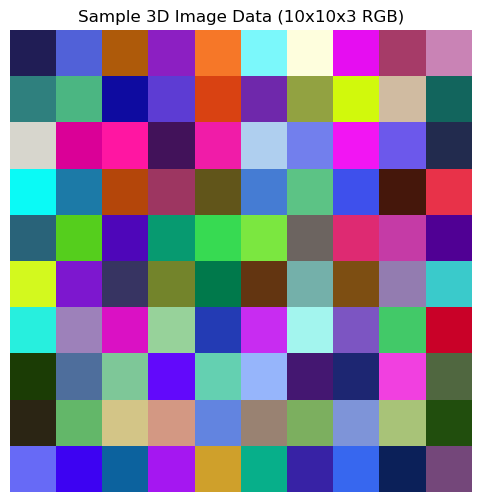

In [1]:
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

# Generate a sample image array (3D: height x width x channels)
image_3d = np.random.randint(0, 256, size=(10, 10, 3), dtype=np.uint8)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image_3d)
plt.title("Sample 3D Image Data (10x10x3 RGB)")
plt.axis('off')
plt.show()


In [10]:
print(image_3d)

[[[ 32  29  85]
  [ 81  97 216]
  [174  90  10]
  [140  31 194]
  [246 119  40]
  [123 248 251]
  [254 254 221]
  [230  13 241]
  [166  59 104]
  [201 131 181]]

 [[ 47 128 126]
  [ 75 182 130]
  [ 14  11 160]
  [ 93  60 211]
  [217  66  18]
  [111  40 171]
  [146 162  65]
  [209 249  12]
  [208 187 161]
  [ 18 101  93]]

 [[215 214 205]
  [218   0 151]
  [255  22 162]
  [ 66  18  90]
  [240  28 168]
  [175 207 239]
  [114 127 237]
  [242  21 243]
  [108  88 235]
  [ 34  43  78]]

 [[ 10 250 246]
  [ 28 122 167]
  [180  70  10]
  [157  54  97]
  [ 97  85  26]
  [ 69 124 211]
  [ 92 195 133]
  [ 62  80 236]
  [ 69  23  11]
  [232  50  73]]

 [[ 41  99 121]
  [ 85 206  29]
  [ 78   6 185]
  [  7 154 112]
  [ 55 218  82]
  [123 231  64]
  [108 100  96]
  [222  42 114]
  [197  59 166]
  [ 80   0 148]]

 [[211 249  30]
  [125  23 207]
  [ 55  52  98]
  [115 132  43]
  [  0 121  75]
  [ 99  53  17]
  [116 176 170]
  [125  78  18]
  [147 124 176]
  [ 58 202 203]]

 [[ 39 239 222]
  [157 129 1

In [6]:
# display the shape and dimensions of the image data as numPy array
print("\nImage shape:", image_3d.shape)
print("Image dimensions:", image_3d.ndim)


Image shape: (10, 10, 3)
Image dimensions: 3


In [11]:
print(image_3d.shape)
print(image_3d[0, 0])      # one pixel
print(image_3d[:, :, 0])   # red channel
print(image_3d[:, :, 1])   # green channel
print(image_3d[:, :, 2])   # blue channel

(10, 10, 3)
[32 29 85]
[[ 32  81 174 140 246 123 254 230 166 201]
 [ 47  75  14  93 217 111 146 209 208  18]
 [215 218 255  66 240 175 114 242 108  34]
 [ 10  28 180 157  97  69  92  62  69 232]
 [ 41  85  78   7  55 123 108 222 197  80]
 [211 125  55 115   0  99 116 125 147  58]
 [ 39 157 218 151  35 200 163 124  66 201]
 [ 27  78 126  98 100 150  68  29 241  80]
 [ 43  99 211 211  98 153 124 126 168  33]
 [103  61  12 165 207   7  55  55  11 116]]
[[ 29  97  90  31 119 248 254  13  59 131]
 [128 182  11  60  66  40 162 249 187 101]
 [214   0  22  18  28 207 127  21  88  43]
 [250 122  70  54  85 124 195  80  23  50]
 [ 99 206   6 154 218 231 100  42  59   0]
 [249  23  52 132 121  53 176  78 124 202]
 [239 129  17 210  59  44 245  85 201   1]
 [ 60 110 199   9 208 181  23  38  64 103]
 [ 37 183 197 152 132 130 175 148 195  78]
 [106   2  98  23 160 175  34 103  32  71]]
[[ 85 216  10 194  40 251 221 241 104 181]
 [126 130 160 211  18 171  65  12 161  93]
 [205 151 162  90 168 239 237

In [12]:

# Convert to DataFrame for analysis
image_flat = image_3d.reshape(-1, 3)
image_df = pd.DataFrame(image_flat, columns=['R', 'G', 'B'])
print("Image data as DataFrame:")
print(image_df)

Image data as DataFrame:
      R    G    B
0    32   29   85
1    81   97  216
2   174   90   10
3   140   31  194
4   246  119   40
..  ...  ...  ...
95    7  175  138
96   55   34  165
97   55  103  239
98   11   32   89
99  116   71  122

[100 rows x 3 columns]


In [14]:
# display the shape and dimensions of the image data from image_df
print("\nDataFrame shape:", image_df.shape)
print("DataFrame dimensions:", image_df.ndim)


DataFrame shape: (100, 3)
DataFrame dimensions: 2


NumPy stores the image with a true 3D shape: height × width × color channels. When we reshape that array and load it into a DataFrame, each row becomes one pixel and each column becomes one color channel, so Pandas represents the data as a 2D table.

A DataFrame is fundamentally 2-dimensional:

- rows
- columns

The third dimension in this case is encoded inside the values for each row, rather than in the DataFrame’s axes.

Pandas can mimic higher-dimensional structure using MultiIndex, but the underlying object is still a 2D DataFrame.

In [15]:
# Create MultiIndex for a panel-like DataFrame
stores = ["Store A", "Store B", "Store C"]
quarters = ["Q1", "Q2", "Q3", "Q4"]

index = pd.MultiIndex.from_product([stores, quarters], names=["Store", "Quarter"])

# Create MultiIndex columns for different metrics
metrics = ["Sales", "Profit", "Expenses"]
columns = pd.MultiIndex.from_product([metrics, ["2024", "2025"]], names=["Metric", "Year"])

panel_df = pd.DataFrame(
    np.random.randint(50, 200, size=(len(index), len(columns))),
    index=index,
    columns=columns
)

# Sort the MultiIndex for proper slicing
panel_df = panel_df.sort_index()

panel_df

Metric          Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1        140  195     90  140      182   96
        Q2        117  136    167  116      124  184
        Q3         52  174     50  168      146  122
        Q4        149   79    157  141      181   91
Store B Q1        184   91     81  120      120   71
        Q2        162  194    127  117      153  174
        Q3        138   72     94  198      120  174
        Q4         84  107     80  156      130  164
Store C Q1         62   81    117  132       93  155
        Q2         67  189    173  131      124  121
        Q3        148  113    127  194      109  193
        Q4        150  150    177  118       63  137

In [16]:
# print the shape and dimensions of the panel DataFrame
print("\nPanel DataFrame shape:", panel_df.shape)
print("Panel DataFrame dimensions:", panel_df.ndim)


Panel DataFrame shape: (12, 6)
Panel DataFrame dimensions: 2


In [17]:
# Example 1: Select data for a specific store using .loc
print("Sales data for Store A:")
print(panel_df.loc['Store A'])

Sales data for Store A:
Metric  Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Quarter                                     
Q1        140  195     90  140      182   96
Q2        117  136    167  116      124  184
Q3         52  174     50  168      146  122
Q4        149   79    157  141      181   91


In [18]:
# Example 2: Select data for a specific quarter across all stores
print("\nQ1 data for all stores:")
print(panel_df.xs('Q1', level='Quarter'))


Q1 data for all stores:
Metric  Sales      Profit      Expenses     
Year     2024 2025   2024 2025     2024 2025
Store                                       
Store A   140  195     90  140      182   96
Store B   184   91     81  120      120   71
Store C    62   81    117  132       93  155


In [20]:
# Example 3: Select specific metric and year combination
print("\nSales for 2024 across all stores and quarters:")
print(panel_df.loc[:, ('Sales', '2024')])


Sales for 2024 across all stores and quarters:
Store    Quarter
Store A  Q1         140
         Q2         117
         Q3          52
         Q4         149
Store B  Q1         184
         Q2         162
         Q3         138
         Q4          84
Store C  Q1          62
         Q2          67
         Q3         148
         Q4         150
Name: (Sales, 2024), dtype: int64


In [22]:
# Example 4: Slice within a single store across quarters
print("\nQ1 to Q3 data for Store A:")
print(panel_df.loc[('Store A', slice('Q1', 'Q3')), :])


Q1 to Q3 data for Store A:
Metric          Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1        140  195     90  140      182   96
        Q2        117  136    167  116      124  184
        Q3         52  174     50  168      146  122


Why Pandas Doesn't Support True 3D DataFrames

Pandas was designed primarily for 2D tabular data analysis, similar to spreadsheets or SQL tables. Adding true 3D support would complicate the API and make operations more complex. Instead, Pandas uses MultiIndex to represent higher-dimensional data when needed, keeping the core DataFrame as a simple 2D structure.

For example, in our image data:
- Each row represents one pixel from the original 3D array
- The columns represent the RGB color channels
- The spatial position (height, width) is lost in the flattening process

To preserve spatial information, you'd need to add columns for pixel coordinates or use a MultiIndex with height/width levels.

In [41]:
# Example: Show how the first few pixels map from 3D array to DataFrame
print("First 5 pixels from original 3D array:")
print("Pixel (0,0):", image_3d[0, 0])  # RGB values for top-left pixel
print("Pixel (0,1):", image_3d[0, 1])  # RGB values for next pixel
print("Pixel (0,2):", image_3d[0, 2])  # RGB values for next pixel
print("Pixel (0,3):", image_3d[0, 3])  # RGB values for next pixel
print("Pixel (0,4):", image_3d[0, 4])  # RGB values for next pixel

print("\nSame pixels in DataFrame (first 5 rows):")
print(image_df.head())

First 5 pixels from original 3D array:
Pixel (0,0): [217 183 147]
Pixel (0,1): [ 91   0 229]
Pixel (0,2): [ 49 226 171]
Pixel (0,3): [230 189 237]
Pixel (0,4): [229 128 134]

Same pixels in DataFrame (first 5 rows):
     R    G    B
0  217  183  147
1   91    0  229
2   49  226  171
3  230  189  237
4  229  128  134


In [23]:
# Pandas Panel: Historical Context

# Panel was a 3D data structure (items × major_axis × minor_axis)
# It was deprecated in Pandas 0.20.0 (May 2017) and removed in Pandas 0.25.0 (September 2019)

# Example of what Panel looked like (historical):
# panel = pd.Panel(data, items=['A', 'B'], major_axis=dates, minor_axis=columns)

# Why it was dropped:
# 1. Limited use cases - most users didn't need true 3D data structures
# 2. Inconsistent API - harder to maintain compared to DataFrame
# 3. MultiIndex is more flexible - can represent N-dimensional data efficiently
# 4. Performance issues - Panel operations were slower than DataFrame operations
# 5. Simplicity - keeping Pandas focused on 2D DataFrames made the library cleaner

# Modern approach: Use MultiIndex instead of Panel
# Our panel_df uses MultiIndex on both rows and columns to achieve panel-like functionality
print("Modern Panel-like structure using MultiIndex:")
print(panel_df)
print("\nThis achieves the same 3D representation without a dedicated Panel class")

Modern Panel-like structure using MultiIndex:
Metric          Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1        140  195     90  140      182   96
        Q2        117  136    167  116      124  184
        Q3         52  174     50  168      146  122
        Q4        149   79    157  141      181   91
Store B Q1        184   91     81  120      120   71
        Q2        162  194    127  117      153  174
        Q3        138   72     94  198      120  174
        Q4         84  107     80  156      130  164
Store C Q1         62   81    117  132       93  155
        Q2         67  189    173  131      124  121
        Q3        148  113    127  194      109  193
        Q4        150  150    177  118       63  137

This achieves the same 3D representation without a dedicated Panel class
